In [1]:
%load_ext autoreload
%autoreload 2  # Autoreload all modules

from utils.paths import *
from utils.constants import *
from utils.analysis import *
from utils.plotting import *
from utils.rootfuncs import *
import numpy as np
import xarray as xr
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import itertools as it
from matplotlib import rcParams
from dateutil.relativedelta import relativedelta
import calendar
from matplotlib.cm import get_cmap
import warnings
from scipy.stats import linregress, pearsonr
import statsmodels.api as statsm
import warnings
from scipy.optimize import minimize 
import warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


warnings.filterwarnings('ignore', category = FutureWarning)
warnings.filterwarnings('ignore', category = pd.errors.PerformanceWarning)

rcParams['font.size'] = 5
rcParams['axes.titlesize'] = 5
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'
rcParams['xtick.major.pad'] = 3
rcParams['ytick.major.pad'] = 3
rcParams['xtick.major.size'] = 1
rcParams['ytick.major.size'] = 1

lab = 'abcdefghijklmnopqrstuvwxyz'

prefix = '20230623'

/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


In [2]:
minirhizotron, ingrowth = get_observation()
annual_minirhizotron_obs, minirhizotron_cycle_mean_obs, minirhizotron_cycle_std_obs, ingrowth_2014_2017_mean_obs, ingrowth_2014_2017_std_obs = convert_observation(minirhizotron, ingrowth)
annual_minirhizotron_sim, minirhizotron_cycle_mean_sim, minirhizotron_cycle_std_sim, ingrowth_2014_2017_mean_sim, ingrowth_2014_2017_std_sim = convert_sims(prefix)

temperature = read_sims_tair_annual()
pheno_obs_sos = read_leaf_sos()
pheno_obs_eos = read_leaf_eos()

/home/ywo/Git/phenology_elm/utils/rootfuncs.py:18: DtypeWarning: Columns (5,6,7,8,9,15,16,19,20,23,24,32,33,39,40,41,49,54,59,467,504,539,546,570,636,757,758,820,846,849,852,858,859,860,861,862,863,864,866,872,875,877,880,889,906,911,935,990,1000,1037) have mixed types. Specify dtype option on import or set low_memory=False.
  cconc = pd.read_csv(os.path.join(path_input, "FRED3_cleaned.csv"))


619 828


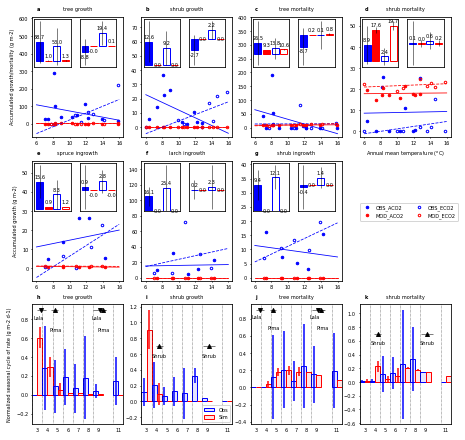

In [6]:
""" Compare the mean and sensitivity in annual minirhizotron and ingrowth core observations """
def _add_bar(ax_inset, x_y_std_list):
    bars = []
    for t in x_y_std_list:
        x, y, std, ec, fc = t
        temp = ax_inset.bar(height = y, x = x, edgecolor = ec, facecolor = fc)
        bars.append(temp[0])
        ax_inset.errorbar(yerr = std, y = y, x = x, color = 'k', lw = 0.5)
    lim = ax_inset.get_ylim()
    for bar in bars:
        yval = bar.get_height()
        ax_inset.text(bar.get_x() + bar.get_width()/2, yval + np.sign(yval) * (lim[1] - lim[0]) / 10,
                      f'{yval:.1f}', ha='center', va='center')


fig, axes = plt.subplots(3, 4, figsize = (7.5, 7.5))

# minirhizotron
count = 0
for a, b in it.product(['g_g_d', 'm_g_d'], ['tree', 'shrub']):
    temp_obs = annual_minirhizotron_obs.loc[:, (a, b)]
    temp_sim = annual_minirhizotron_sim.loc[:, (a, b)]
    temp = temperature.loc[temp_obs.index, :]

    ax = axes[0, count]

    # (mean)
    inset_ax1 = inset_axes(ax, width="100%", height="100%", loc='upper right', bbox_to_anchor=(0.05, 0.6, 0.4, 0.4), bbox_transform=ax.transAxes)
    inset_ax1.set_xticks([])
    inset_ax1.set_yticks([])

    # (slope)
    inset_ax2 = inset_axes(ax, width="100%", height="100%", loc='upper right', bbox_to_anchor=(0.55, 0.6, 0.4, 0.4), bbox_transform=ax.transAxes)
    inset_ax2.set_xticks([])
    inset_ax2.set_yticks([])

    inset_ax1_data = []
    inset_ax2_data = []

    for c, co2 in enumerate(['ACO2', 'ECO2']):
        if co2 == 'ACO2':
            chambers = chamber_list_complete[1::2] # skip ambient
            fc = ['b', 'r']
            ls = '-'
        else:
            chambers = chamber_list_complete[2::2]
            fc = ['none', 'none']
            ls = '--'
        temp_obs_temp = temp_obs.loc[:, chambers].values.reshape(-1)
        temp_sim_temp = temp_sim.loc[:, chambers].values.reshape(-1)
        temp_temp = temp.loc[:, chambers].values.reshape(-1)

        filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp) | np.isnan(temp_temp))

        ax.plot(temp_temp[filt], temp_obs_temp[filt], 'ob', markerfacecolor = fc[0], label = f'OBS_{co2}', ms = 2.5)
        res_obs = statsm.OLS(temp_obs_temp[filt], statsm.add_constant(temp_temp[filt])).fit()
        ax.plot([6, 16], [6 * res_obs.params[1] + res_obs.params[0], 16 * res_obs.params[1] + res_obs.params[0]], ls = ls, color = 'b', lw = 0.8)

        ax.plot(temp_temp[filt], temp_sim_temp[filt], 'or', markerfacecolor = fc[1], label = f'MOD_{co2}', ms = 2.5)
        res_sim = statsm.OLS(temp_sim_temp[filt], statsm.add_constant(temp_temp[filt])).fit()
        ax.plot([6, 16], [6 * res_sim.params[1] + res_sim.params[0], 16 * res_sim.params[1] + res_sim.params[0]], ls = ls, color = 'r', lw = 0.8)

        inset_ax1_data.append((c*2, np.nanmean(temp_obs_temp), np.nanstd(temp_obs_temp), 'b', fc[0]))
        inset_ax1_data.append((c*2 + 1, np.nanmean(temp_sim_temp), np.nanstd(temp_sim_temp), 'r', fc[1]))
        inset_ax2_data.append((c*2, res_obs.params[1], np.abs(res_obs.conf_int()[1, :].reshape(-1,1) - res_obs.params[1]), 'b', fc[0]))
        inset_ax2_data.append((c*2 + 1, res_sim.params[1], np.abs(res_sim.conf_int()[1, :].reshape(-1,1) - res_sim.params[1]), 'r', fc[1]))

    _add_bar(inset_ax1, inset_ax1_data)
    _add_bar(inset_ax2, inset_ax2_data)

    if a == 'm_g_d':
        title = f'{b} mortality'
    else:
        title = f'{b} growth'
    ax.set_title(title)
    ax.text(0.05, 1.05, lab[count], transform = ax.transAxes, fontweight = 'bold')

    ylim = ax.get_ylim()
    ax.set_ylim([ylim[0], ylim[1] * 2])
    if count == 0:
        ax.set_ylabel('Accumulated growth/mortality (g m-2)')

    if count >= 3:
        ax.set_xlabel('Annual mean temperature ($^o$C)')

    count = count + 1

count = 0
for name in ['spruce', 'larch', 'shrub']:
    temp_obs = ingrowth_2014_2017_mean_obs.loc[name, :]
    temp_sim = ingrowth_2014_2017_mean_sim.loc[name, :]
    temp = temperature.loc[2014:2017, :].mean(axis = 0)

    ax = axes[1, count]

    # (mean)
    inset_ax1 = inset_axes(ax, width="100%", height="100%", loc='upper right', bbox_to_anchor=(0.05, 0.6, 0.4, 0.4), bbox_transform=ax.transAxes)
    inset_ax1.set_xticks([])
    inset_ax1.set_yticks([])

    # (slope)
    inset_ax2 = inset_axes(ax, width="100%", height="100%", loc='upper right', bbox_to_anchor=(0.55, 0.6, 0.4, 0.4), bbox_transform=ax.transAxes)
    inset_ax2.set_xticks([])
    inset_ax2.set_yticks([])

    inset_ax1_data = []
    inset_ax2_data = [] 

    for c, co2 in enumerate(['ACO2', 'ECO2']):
        if co2 == 'ACO2':
            chambers = chamber_list_complete[1::2] # skip ambient
            fc = ['b', 'r']
            ls = '-'
        else:
            chambers = chamber_list_complete[2::2]
            fc = ['none', 'none']
            ls = '--'
        temp_obs_temp = temp_obs.loc[chambers].values
        temp_sim_temp = temp_sim.loc[chambers].values
        temp_temp = temp.loc[chambers].values

        filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp) | np.isnan(temp_temp))

        ax.plot(temp_temp[filt], temp_obs_temp[filt], 'ob', markerfacecolor = fc[0], label = f'OBS_{co2}', ms = 2.5)
        res_obs = statsm.OLS(temp_obs_temp[filt], statsm.add_constant(temp_temp[filt])).fit()
        ax.plot([6, 16], [6 * res_obs.params[1] + res_obs.params[0], 16 * res_obs.params[1] + res_obs.params[0]], ls = ls, color = 'b', lw = 0.8)

        ax.plot(temp_temp[filt], temp_sim_temp[filt], 'or', markerfacecolor = fc[1], label = f'MOD_{co2}', ms = 2.5)
        res_sim = statsm.OLS(temp_sim_temp[filt], statsm.add_constant(temp_temp[filt])).fit()
        ax.plot([6, 16], [6 * res_sim.params[1] + res_sim.params[0], 16 * res_sim.params[1] + res_sim.params[0]], ls = ls, color = 'r', lw = 0.8)

        inset_ax1_data.append((c*2, np.nanmean(temp_obs_temp), np.nanstd(temp_obs_temp), 'b', fc[0]))
        inset_ax1_data.append((c*2 + 1, np.nanmean(temp_sim_temp), np.nanstd(temp_sim_temp), 'r', fc[1]))
        inset_ax2_data.append((c*2, res_obs.params[1], np.abs(res_obs.conf_int()[1, :].reshape(-1,1) - res_obs.params[1]), 'b', fc[0]))
        inset_ax2_data.append((c*2 + 1, res_sim.params[1], np.abs(res_sim.conf_int()[1, :].reshape(-1,1) - res_sim.params[1]), 'r', fc[1]))

    ax.set_title(f'{name} ingrowth')
    ylim = ax.get_ylim()
    ax.set_ylim([ylim[0], ylim[1] * 2])
    ax.text(0.05, 1.05, lab[count + 4], transform = ax.transAxes, fontweight = 'bold')
    if count == 0:
        ax.set_ylabel('Accumulated growth (g m-2)')

    _add_bar(inset_ax1, inset_ax1_data)
    _add_bar(inset_ax2, inset_ax2_data)

    count = count + 1
ax.legend(loc = [1.2, 0.5], ncol = 2)
axes[1, 3].axis('off')


count = 0
for a, b in it.product(['g_g_d', 'm_g_d'], ['tree', 'shrub']):
    temp_obs = minirhizotron_cycle_mean_obs.loc[:, (a, b)]
    temp_sim = minirhizotron_cycle_mean_sim.loc[:, (a, b)]
    temp_obs_std = minirhizotron_cycle_std_obs.loc[:, (a, b)]
    temp_sim_std = minirhizotron_cycle_std_sim.loc[:, (a, b)]

    ax = axes[2, count]

    xticks = []
    xticklabels = []
    for j, month in enumerate(temp_obs.index):
        width = 1
        h1 = ax.bar(month, temp_obs.loc[month], width = width / 2, align = 'edge', facecolor = 'b', edgecolor = 'b', lw = 1)
        h1[0].set_facecolor((0, 0, 1, 0.1))  # RGBa: blue with alpha
        h2 = ax.bar(month + width / 2, temp_sim.loc[month], width = width / 2, align = 'edge', facecolor = 'r', edgecolor = 'r', lw = 1)
        h2[0].set_facecolor((1, 0, 0, 0.1))  # RGBa: red with alpha

        ax.errorbar(month + width / 4, temp_obs.loc[month], yerr = temp_obs_std.loc[month], ecolor = 'b')
        ax.errorbar(month + width * 3 / 4, temp_sim.loc[month], yerr = temp_sim_std.loc[month], ecolor = 'r')

        xticks.append(month)
        xticklabels.append(str(month))
    

    for pheno_obs in [pheno_obs_sos, pheno_obs_eos]:
        if b == 'shrub':
            doy = pheno_obs['SH'].mean(axis = 0).mean()
            xloc = datetime(2018, 1, 1) + relativedelta(days = doy)
            xloc = xloc.month + xloc.day / 30 - 0.5
            ax.scatter(xloc, 0.7, marker = '^', color = 'k', s = 15)
            ax.text(xloc, 0.55, 'Shrub', ha = 'center')

            doy_std = pheno_obs['SH'].stack().std()
            xloc_min = datetime(2018, 1, 1) + relativedelta(days = doy - doy_std)
            xloc_min = xloc_min.month + xloc_min.day / 30 - 0.5
            xloc_max = datetime(2018, 1, 1) + relativedelta(days = doy + doy_std)
            xloc_max = xloc_max.month + xloc_max.day / 30 - 0.5
            ax.errorbar(x = xloc, y = 0.7, xerr = np.array([[xloc - xloc_min], [xloc_max - xloc]]), color = 'k', lw = 0.5)
        else:
            doy_spruce = pheno_obs['EN'].mean(axis = 0).mean()
            xloc_spruce = datetime(2018, 1, 1) + relativedelta(days = doy_spruce)
            xloc_spruce = xloc_spruce.month + xloc_spruce.day / 30 - 0.5

            ax.scatter(xloc_spruce, 0.9, marker = '^', color = 'k', s = 15)
            ax.text(xloc_spruce - 0.5, 0.675, 'Pima')

            doy_spruce_std = pheno_obs['EN'].stack().std()
            xloc_spruce_min = datetime(2018, 1, 1) + relativedelta(days = doy_spruce - doy_spruce_std)
            xloc_spruce_min = xloc_spruce_min.month + xloc_spruce_min.day / 30 - 0.5
            xloc_spruce_max = datetime(2018, 1, 1) + relativedelta(days = doy_spruce + doy_spruce_std)
            xloc_spruce_max = xloc_spruce_max.month + xloc_spruce_max.day / 30 - 0.5
            ax.errorbar(x = xloc_spruce, y = 0.9, xerr = np.array([[xloc_spruce - xloc_spruce_min], [xloc_spruce_max - xloc_spruce]]), color = 'k', lw = 0.5)

            doy_larch = pheno_obs['DN'].mean(axis = 0).mean()
            xloc_larch = datetime(2018, 1, 1) + relativedelta(days = doy_larch)
            xloc_larch = xloc_larch.month + xloc_larch.day / 30 - 0.5

            ax.scatter(xloc_larch, 0.9, marker = 'v', color = 'k', s = 15)
            ax.text(xloc_larch - 0.8, 0.8, 'Lala')

            doy_larch_std = pheno_obs['DN'].stack().std()
            xloc_larch_min = datetime(2018, 1, 1) + relativedelta(days = doy_larch - doy_larch_std)
            xloc_larch_min = xloc_larch_min.month + xloc_larch_min.day / 30 - 0.5
            xloc_larch_max = datetime(2018, 1, 1) + relativedelta(days = doy_larch + doy_larch_std)
            xloc_larch_max = xloc_larch_max.month + xloc_larch_max.day / 30 - 0.5
            ax.errorbar(x = xloc_larch, y = 0.9, 
                        xerr = np.array([[xloc_larch - xloc_larch_min], [xloc_larch_max - xloc_larch]]), 
                        color = 'k', lw = 0.5)

    if count == 1:
        ax.legend([h1, h2], ['Obs', 'Sim'], loc = 'lower right') 

    if a == 'm_g_d':
        title = f'{b} mortality'
    else:
        title = f'{b} growth'
    ax.set_title(title)
    if count == 0:
        ax.set_ylabel('Normalized seasonal cycle of rate (g m-2 d-1)')

    ax.set_xlim([temp_obs.index.min(), temp_obs.index.max() + 1])
    ax.tick_params(length = 0, axis = 'x', which = 'both')
    ax.set_xticks(xticks)
    ax.set_xticks(np.array(xticks) + 0.5, minor = True)
    ax.set_xticklabels([])
    ax.set_xticklabels(xticklabels, minor = True)
    ax.text(0.05, 1.05, lab[count + 7], transform = ax.transAxes, fontweight = 'bold')

    ax.grid(which = 'major', axis = 'x', ls = ':', lw = 0.5, color = 'k')

    count = count + 1

plt.savefig(os.path.join(path_out, f'process_root_analysis_annual_{prefix}.png'), 
            dpi = 600., bbox_inches = 'tight')

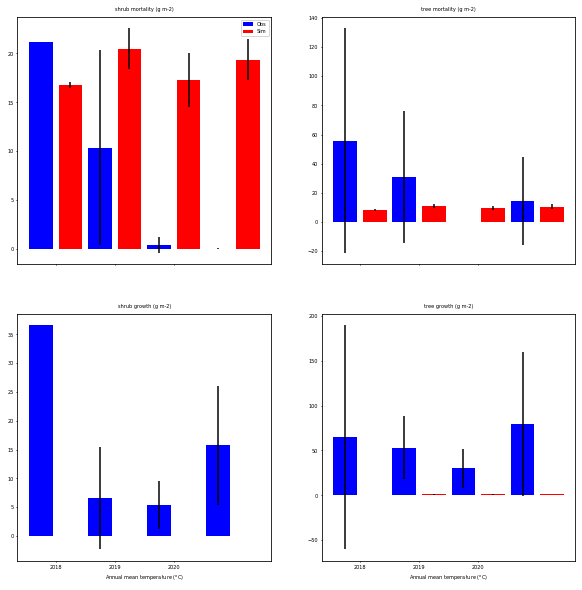

In [4]:
# plot the annual values as bar plots
annual_minirhizotron_sim2 = annual_minirhizotron_sim.copy()
annual_minirhizotron_sim2[annual_minirhizotron_obs.isna()] = np.nan

fig, axes = plt.subplots(2, 2, figsize = (10, 10), sharex = True)
count = 0
for a, b in it.product(['m_g_d', 'g_g_d'], ['shrub', 'tree']):
    ax = axes.flat[count]

    for i, y in enumerate([2015, 2018, 2019, 2020]):
        temp_obs = annual_minirhizotron_obs.loc[y, (a, b)]
        temp_sim = annual_minirhizotron_sim.loc[y, (a, b)]

        ax.bar(i * 2, temp_obs.mean(), color = 'b', label = 'Obs')
        ax.errorbar(i * 2, temp_obs.mean(), temp_obs.std(), ecolor = 'k')

        ax.bar(i * 2 + 1, temp_sim.mean(), color = 'r', label = 'Sim')
        ax.errorbar(i * 2 + 1, temp_sim.mean(), temp_sim.std(), ecolor = 'k')

        if count == 0 and i == 0:
            ax.legend()
    
    ax.set_xticks([0.5, 2.5, 4.5])
    ax.set_xticklabels(['2018', '2019', '2020'])

    if a == 'm_g_d':
        title = f'{b} mortality (g m-2)'
    else:
        title = f'{b} growth (g m-2)'
    ax.set_title(title)

    if count >= 2:
        ax.set_xlabel('Annual mean temperature ($^o$C)')

    count = count + 1

In [5]:
# statistic
annual_minirhizotron_errors = pd.DataFrame(np.nan, index = pd.MultiIndex.from_product([['m_g_d', 'g_g_d'], ['shrub', 'tree']]),
                                           columns = ['bias', 'rmse', 'corr', 'corr_p'])
for a, b in it.product(['m_g_d', 'g_g_d'], ['shrub', 'tree']):
    temp_obs = annual_minirhizotron_obs.loc[:, (a, b)]
    temp_sim = annual_minirhizotron_sim.loc[:, (a, b)]
    temp_obs_temp = temp_obs.loc[:, chamber_list_complete].values.reshape(-1)
    temp_sim_temp = temp_sim.loc[:, chamber_list_complete].values.reshape(-1)
    filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp))
    temp_obs_temp = temp_obs_temp[filt]
    temp_sim_temp = temp_sim_temp[filt]
    annual_minirhizotron_errors.loc[(a, b), 'bias'] = np.mean(temp_sim_temp) - np.mean(temp_obs_temp)
    annual_minirhizotron_errors.loc[(a, b), 'rmse'] = np.sqrt(np.mean(np.power(temp_sim_temp - temp_obs_temp, 2)))
    rho, pval = pearsonr(temp_sim_temp, temp_obs_temp)
    annual_minirhizotron_errors.loc[(a, b), 'corr'] = rho
    annual_minirhizotron_errors.loc[(a, b), 'corr_p'] = pval
print(annual_minirhizotron_errors)


# statistic
ingrowth_2014_2017_errors = pd.DataFrame(np.nan, index = ['spruce', 'larch', 'shrub'],
                                        columns = ['bias', 'rmse', 'corr', 'corr_p'])
for name in ['spruce', 'larch', 'shrub']:
    temp_obs = ingrowth_2014_2017_mean_obs.loc[name, :]
    temp_sim = ingrowth_2014_2017_mean_sim.loc[name, :]
    temp_obs_temp = temp_obs.loc[chamber_list].values.reshape(-1)
    temp_sim_temp = temp_sim.loc[chamber_list].values.reshape(-1)
    filt = ~(np.isnan(temp_obs_temp) | np.isnan(temp_sim_temp))
    temp_obs_temp = temp_obs_temp[filt]
    temp_sim_temp = temp_sim_temp[filt]
    ingrowth_2014_2017_errors.loc[name, 'bias'] = np.mean(temp_sim_temp) - np.mean(temp_obs_temp)
    ingrowth_2014_2017_errors.loc[name, 'rmse'] = np.sqrt(np.mean(np.power(temp_sim_temp - temp_obs_temp, 2)))
    rho, pval = pearsonr(temp_sim_temp, temp_obs_temp)
    ingrowth_2014_2017_errors.loc[name, 'corr'] = rho
    ingrowth_2014_2017_errors.loc[name, 'corr_p'] = pval
print(ingrowth_2014_2017_errors)

                  bias       rmse      corr    corr_p
m_g_d shrub  13.833212  16.504130  0.039021  0.866638
      tree  -13.337306  47.308900 -0.115308  0.600339
g_g_d shrub  -9.845107  14.292568       NaN       NaN
      tree  -56.521781  90.856172  0.247112  0.255640
             bias       rmse      corr   corr_p
spruce -10.899045  14.589554 -0.276428  0.43944
larch  -20.726832  28.509759       NaN      NaN
shrub  -10.733174  11.862709       NaN      NaN


/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())
